Fetching data for ['TSLA', 'BND', 'SPY'] from 2015-01-01 to 2026-06-30...


[*********************100%***********************]  3 of 3 completed



Missing values per asset:
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64

Data successfully saved to data/processed/

Descriptive Statistics of Daily Returns:
Ticker          BND          SPY         TSLA
count   2887.000000  2887.000000  2887.000000
mean       0.000079     0.000573     0.001803
std        0.003347     0.011121     0.036018
min       -0.054385    -0.109424    -0.210628
25%       -0.001511    -0.003700    -0.016643
50%        0.000134     0.000655     0.001216
75%        0.001773     0.005930     0.019456
max        0.042201     0.105020     0.226900


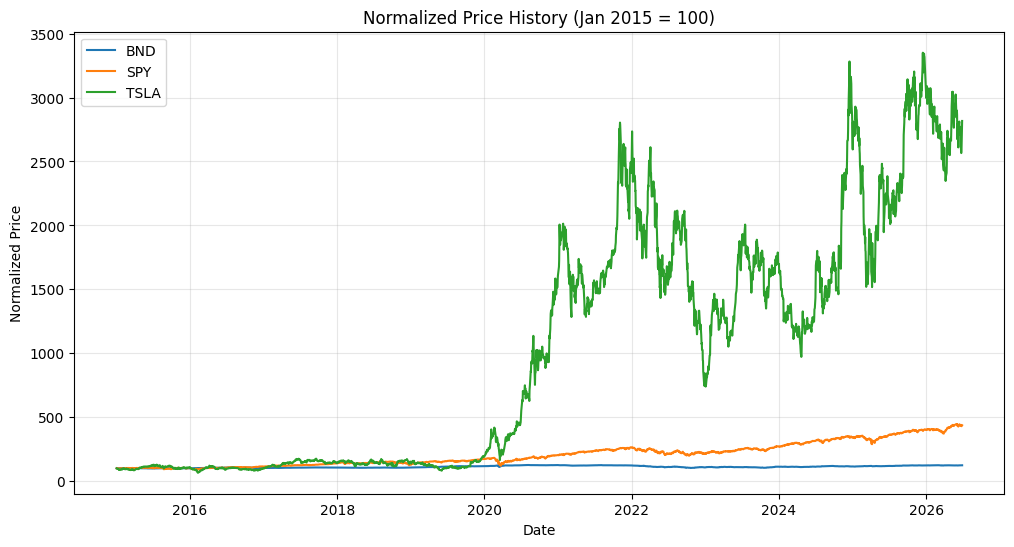

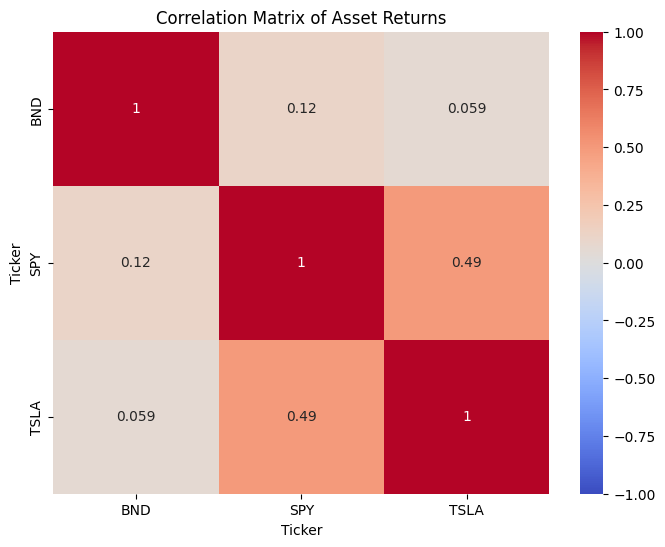

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Define parameters
tickers = ["TSLA", "BND", "SPY"]
start_date = "2015-01-01"
end_date = "2026-06-30"

# 2. Extract Historical Financial Data
print(f"Fetching data for {tickers} from {start_date} to {end_date}...")
raw_data = yf.download(tickers, start=start_date, end=end_date)

# Extract only the 'Adj Close' prices for modeling, as they account for dividends and stock splits
# If 'Adj Close' is unavailable (sometimes happens with yfinance updates), fallback to 'Close'
if 'Adj Close' in raw_data.columns:
    df_prices = raw_data['Adj Close']
else:
    df_prices = raw_data['Close']

# Extract trading volume for exploratory analysis
df_volume = raw_data['Volume']

# 3. Data Cleaning & Preprocessing
# Check for missing values
missing_values = df_prices.isnull().sum()
print("\nMissing values per asset:")
print(missing_values)

# Forward fill missing values (common practice for financial time series, assuming price stays the same on non-trading days)
df_prices = df_prices.ffill().bfill() 

# Calculate daily returns (percentage change), which is critical for portfolio optimization
df_returns = df_prices.pct_change().dropna()

# 4. Save the organized data to your 'data/processed' directory
os.makedirs('../data/processed', exist_ok=True) # Ensure directory exists relative to notebooks folder
df_prices.to_csv('../data/processed/asset_prices.csv')
df_returns.to_csv('../data/processed/asset_returns.csv')
print("\nData successfully saved to data/processed/")

# 5. Exploratory Data Analysis (EDA)
# Display basic statistical properties
print("\nDescriptive Statistics of Daily Returns:")
print(df_returns.describe())

# Plotting Normalized Prices to compare trends
plt.figure(figsize=(12, 6))
normalized_prices = df_prices / df_prices.iloc[0] * 100
for c in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[c], label=c)
    
plt.title('Normalized Price History (Jan 2015 = 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plotting the Correlation Matrix (Important for diversification)
plt.figure(figsize=(8, 6))
sns.heatmap(df_returns.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Asset Returns')
plt.show()

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load the data we saved in the previous step (if running in a new session)
# df_prices = pd.read_csv('../data/processed/asset_prices.csv', index_col=0, parse_dates=True)

print("==== STEP 1 & 2: Data Types and Basic Statistics ====")
# info() checks if our dates are properly formatted as a DatetimeIndex and checks for non-numeric data
print("--- Data Info ---")
df_prices.info() 

print("\n--- Summary Statistics ---")
display(df_prices.describe().T) # .T transposes it to make it easier to read

print("\n==== STEP 3: Handling Missing Values ====")
print("Missing values before processing:")
print(df_prices.isnull().sum())

# For financial time series, time-based interpolation is often superior to simple forward-filling 
# because it estimates a linear path between missing dates rather than just copying the last known price.
df_prices_cleaned = df_prices.interpolate(method='time')

# Re-calculate returns on the strictly cleaned price data
df_returns_cleaned = df_prices_cleaned.pct_change().dropna()

print("\nMissing values after processing:")
print(df_prices_cleaned.isnull().sum())


print("\n==== STEP 4: Normalization / Scaling ====")
# Machine Learning models (like LSTMs or regressions) converge much faster and perform better 
# when features are on a similar scale. 

# Method A: Min-Max Scaling (Bounds data strictly between 0 and 1)
min_max_scaler = MinMaxScaler()
scaled_prices_array = min_max_scaler.fit_transform(df_prices_cleaned)
df_minmax_scaled = pd.DataFrame(
    scaled_prices_array, 
    columns=df_prices_cleaned.columns, 
    index=df_prices_cleaned.index
)

# Method B: Standard Scaling (Transforms data to have a mean of 0 and standard dev of 1)
# Good if you suspect your data has outliers and you want to preserve their impact.
std_scaler = StandardScaler()
scaled_returns_array = std_scaler.fit_transform(df_returns_cleaned)
df_std_scaled_returns = pd.DataFrame(
    scaled_returns_array,
    columns=df_returns_cleaned.columns,
    index=df_returns_cleaned.index
)

print("\n--- Preview of Min-Max Scaled Prices (0 to 1) ---")
display(df_minmax_scaled.head())

print("\n--- Preview of Standard Scaled Returns (Mean=0, Std=1) ---")
display(df_std_scaled_returns.head())

# Save the ML-ready scaled data
df_minmax_scaled.to_csv('../data/processed/scaled_asset_prices.csv')
df_std_scaled_returns.to_csv('../data/processed/scaled_asset_returns.csv')
print("\n✅ Scaled datasets saved to data/processed/")

==== STEP 1 & 2: Data Types and Basic Statistics ====
--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BND     2888 non-null   float64
 1   SPY     2888 non-null   float64
 2   TSLA    2888 non-null   float64
dtypes: float64(3)
memory usage: 90.2 KB

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
BND,2888.0,66.503053,4.713607,58.729176,62.478093,65.728394,70.689154,74.832901
SPY,2888.0,351.505532,155.443934,154.161621,223.546818,312.817886,432.806808,757.618225
TSLA,2888.0,148.773923,138.895957,9.578000,18.393499,133.437668,251.925831,489.880005



==== STEP 3: Handling Missing Values ====
Missing values before processing:
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64

Missing values after processing:
Ticker
BND     0
SPY     0
TSLA    0
dtype: int64

==== STEP 4: Normalization / Scaling ====

--- Preview of Min-Max Scaled Prices (0 to 1) ---


Ticker,BND,SPY,TSLA
Date,,,
2015-01-02,0.041992,0.025729,0.010499
2015-01-05,0.052704,0.020651,0.009219
2015-01-06,0.063416,0.018050,0.009384
2015-01-07,0.065648,0.021458,0.009339
2015-01-08,0.059846,0.026372,0.009293



--- Preview of Standard Scaled Returns (Mean=0, Std=1) ---


Ticker,BND,SPY,TSLA
Date,,,
2015-01-05,0.844063,-1.675650,-1.217465
2015-01-06,0.841474,-0.898587,0.107233
2015-01-07,0.156117,1.069191,-0.093426
2015-01-08,-0.490673,1.544346,-0.093492
2015-01-09,0.479994,-0.772199,-0.572144



✅ Scaled datasets saved to data/processed/


==== EXPLORATORY DATA ANALYSIS (EDA) ====



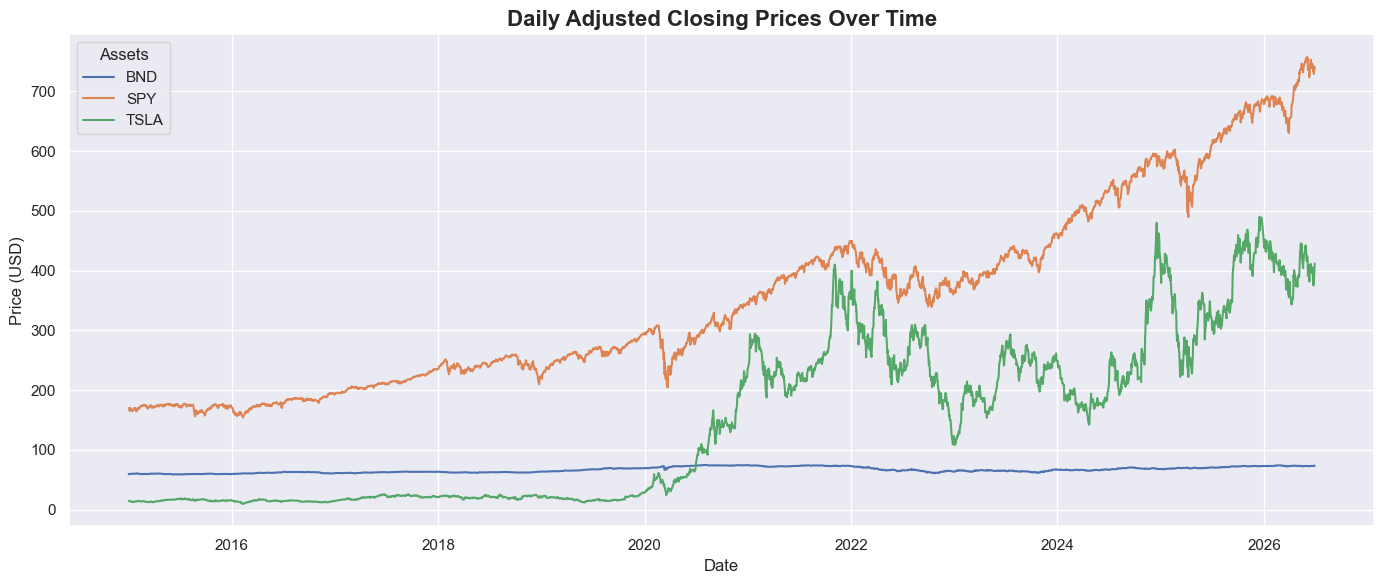

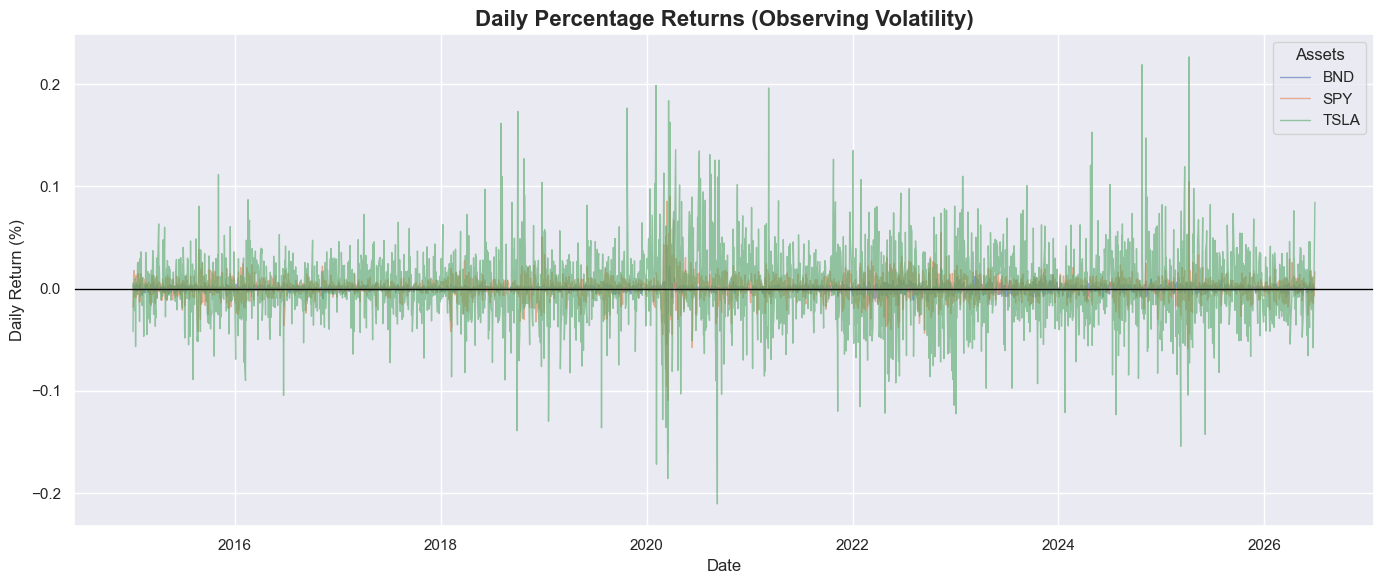

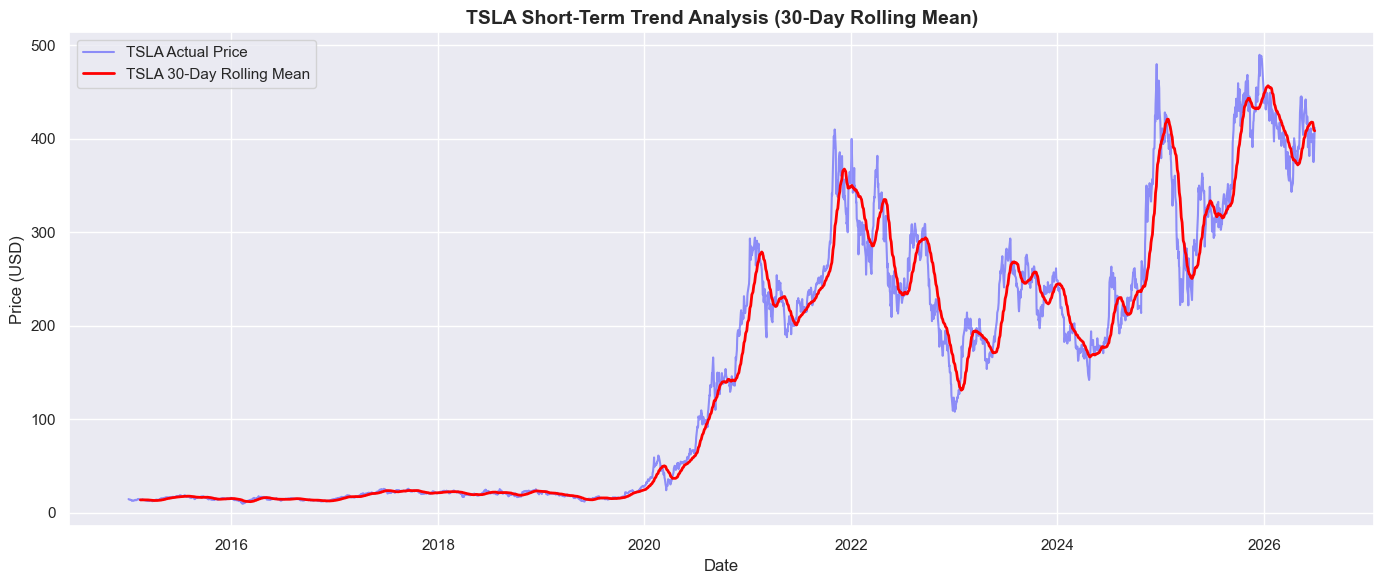

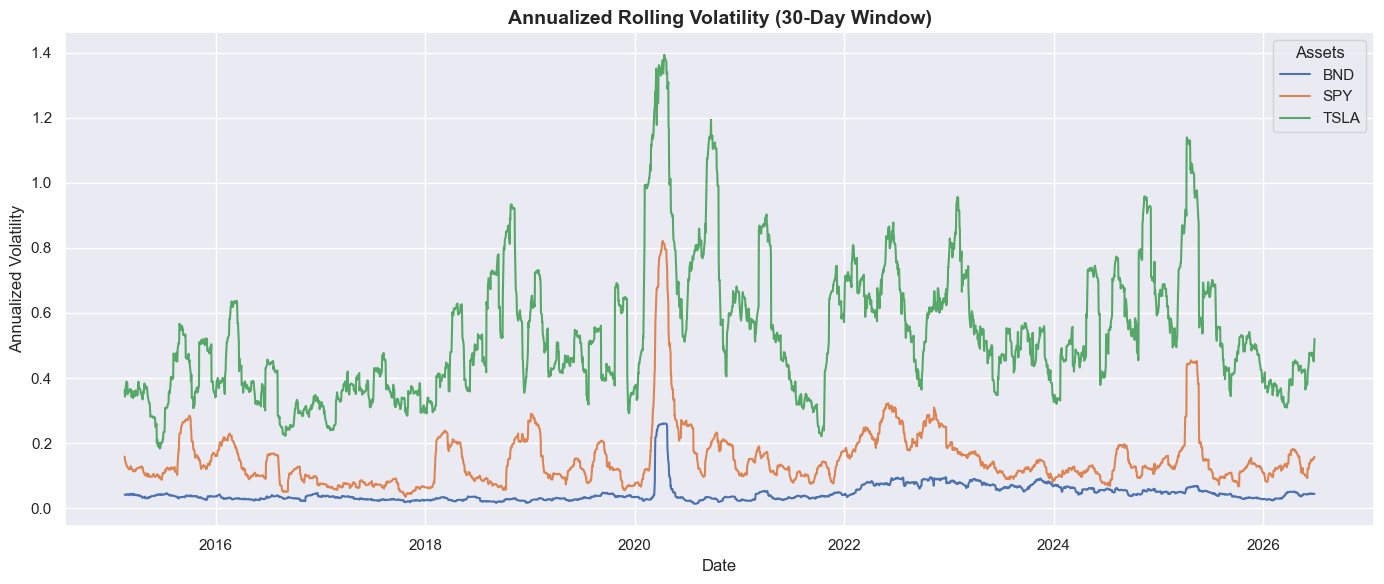

==== OUTLIER DETECTION ====

--- Asset: BND ---
Mean Return: 0.0001 | Std Dev: 0.0033
Thresholds: > 0.0101 (High) | < -0.0100 (Low)
Total Outlier Days: 33
Top 3 Largest Positive Returns (Anomalies):


Date
2020-03-13    0.042201
2020-03-23    0.022149
2022-11-10    0.020702
Name: BND, dtype: float64

Top 3 Largest Negative Returns (Anomalies):


Date
2020-03-12   -0.054385
2020-03-18   -0.024140
2020-03-17   -0.020686
Name: BND, dtype: float64

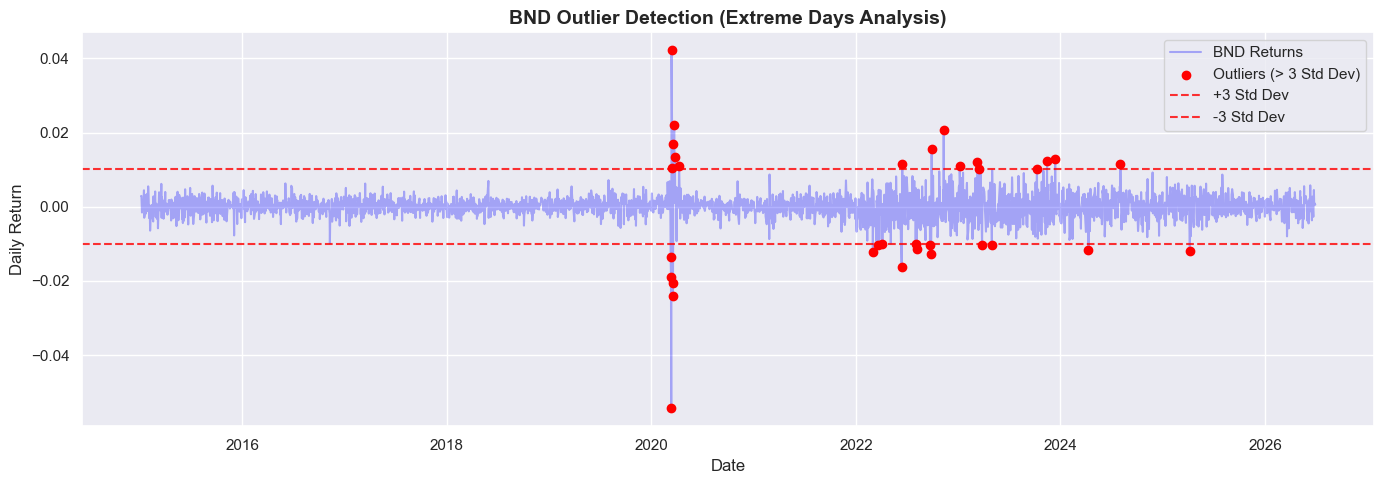


--- Asset: SPY ---
Mean Return: 0.0006 | Std Dev: 0.0111
Thresholds: > 0.0339 (High) | < -0.0328 (Low)
Total Outlier Days: 39
Top 3 Largest Positive Returns (Anomalies):


Date
2025-04-09    0.105020
2020-03-24    0.090603
2020-03-13    0.085486
Name: SPY, dtype: float64

Top 3 Largest Negative Returns (Anomalies):


Date
2020-03-16   -0.109424
2020-03-12   -0.095677
2020-03-09   -0.078095
Name: SPY, dtype: float64

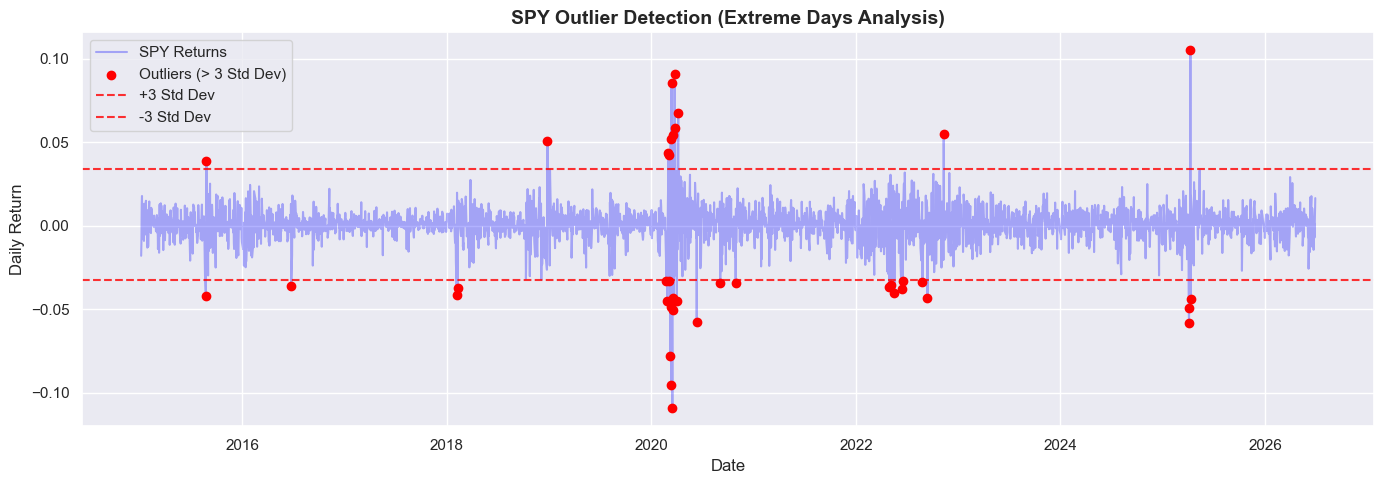


--- Asset: TSLA ---
Mean Return: 0.0018 | Std Dev: 0.0360
Thresholds: > 0.1099 (High) | < -0.1063 (Low)
Total Outlier Days: 46
Top 3 Largest Positive Returns (Anomalies):


Date
2025-04-09    0.226900
2024-10-24    0.219190
2020-02-03    0.198949
Name: TSLA, dtype: float64

Top 3 Largest Negative Returns (Anomalies):


Date
2020-09-08   -0.210628
2020-03-16   -0.185778
2020-02-05   -0.171758
Name: TSLA, dtype: float64

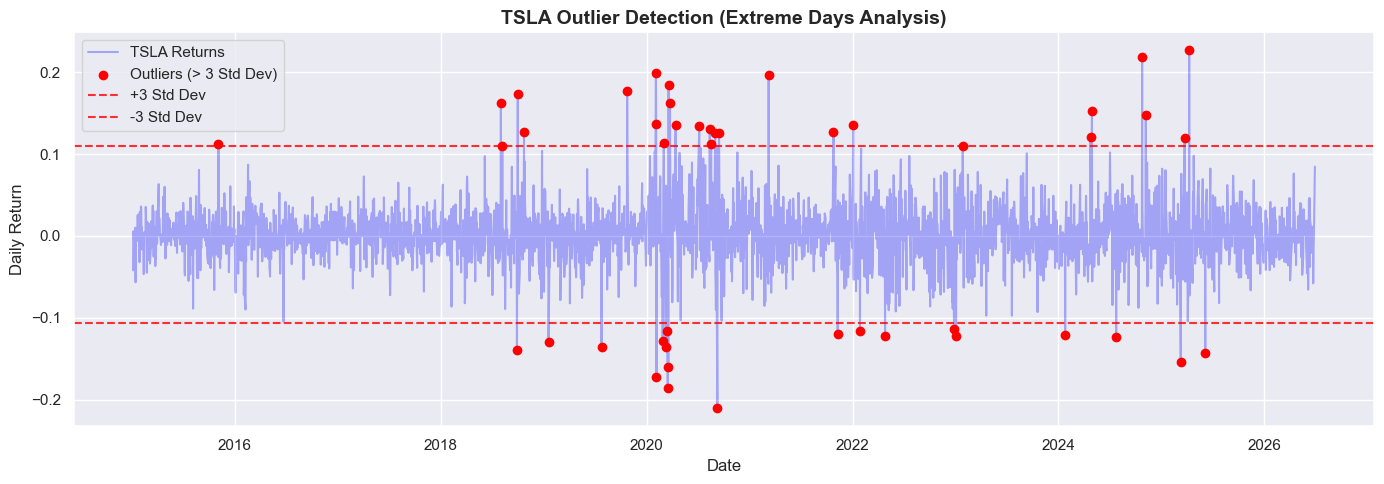


==== SEASONALITY AND TREND ANALYSIS ====
Augmented Dickey-Fuller (ADF) Test for Stationarity
Hypothesis: A p-value < 0.05 indicates the time series is stationary.

[Testing Closing Prices]
--- BND Price ---
ADF Statistic: -1.0827
p-value: 0.7219 -> Non-Stationary
--- SPY Price ---
ADF Statistic: 1.3089
p-value: 0.9967 -> Non-Stationary
--- TSLA Price ---
ADF Statistic: -1.0696
p-value: 0.7270 -> Non-Stationary

[Testing Daily Returns]
--- BND Return ---
ADF Statistic: -15.2161
p-value: 0.0000 -> Stationary
--- SPY Return ---
ADF Statistic: -17.5722
p-value: 0.0000 -> Stationary
--- TSLA Return ---
ADF Statistic: -53.9719
p-value: 0.0000 -> Stationary

--- Implications for Modeling (ARIMA) ---
1. Prices are generally Non-Stationary. They contain trends and do not revert to a steady mean.
   -> A non-stationary series requires differencing (the 'd' in ARIMA) to become stationary, which is a prerequisite for the model.
2. Daily Returns are generally Stationary. They represent the first-o

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller

# Set a clean visual style for the EDA charts
sns.set_theme(style="darkgrid")

print("==== EXPLORATORY DATA ANALYSIS (EDA) ====\n")

# ==========================================
# 1. Visualize closing price over time (Trends & Patterns)
# ==========================================
plt.figure(figsize=(14, 6))
for col in df_prices_cleaned.columns:
    plt.plot(df_prices_cleaned.index, df_prices_cleaned[col], label=col, linewidth=1.5)

plt.title('Daily Adjusted Closing Prices Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(title='Assets')
plt.tight_layout()
plt.show()

# ==========================================
# 2. Plot the daily percentage change (Volatility)
# ==========================================
plt.figure(figsize=(14, 6))
for col in df_returns_cleaned.columns:
    # Adding alpha makes overlapping lines easier to read
    plt.plot(df_returns_cleaned.index, df_returns_cleaned[col], label=col, alpha=0.6, linewidth=1)

plt.title('Daily Percentage Returns (Observing Volatility)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Return (%)', fontsize=12)
plt.axhline(0, color='black', linestyle='-', linewidth=1) # Zero-line for reference
plt.legend(title='Assets')
plt.tight_layout()
plt.show()

# ==========================================
# 3. Analyze volatility via rolling means and standard deviations
# ==========================================
window_size = 30 # 30 trading days (~1.5 months)

# 3A. Rolling Mean (Short-term Trends)
rolling_mean = df_prices_cleaned.rolling(window=window_size).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_prices_cleaned.index, df_prices_cleaned['TSLA'], label='TSLA Actual Price', alpha=0.4, color='blue')
plt.plot(rolling_mean.index, rolling_mean['TSLA'], label=f'TSLA {window_size}-Day Rolling Mean', color='red', linewidth=2)
plt.title(f'TSLA Short-Term Trend Analysis ({window_size}-Day Rolling Mean)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# 3B. Rolling Standard Deviation (Short-term Fluctuations/Volatility)
# We multiply by sqrt(252) to annualize the daily volatility, a common finance practice
rolling_std = df_returns_cleaned.rolling(window=window_size).std() * np.sqrt(252)

plt.figure(figsize=(14, 6))
for col in rolling_std.columns:
    plt.plot(rolling_std.index, rolling_std[col], label=col, linewidth=1.5)

plt.title(f'Annualized Rolling Volatility ({window_size}-Day Window)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend(title='Assets')
plt.tight_layout()
plt.show()

# ==========================================
# 4 & 5. Outlier Detection & Extreme Days Analysis
# ==========================================
print("==== OUTLIER DETECTION ====")
# In finance, a return greater than 3 Standard Deviations from the mean is considered a significant anomaly.

for col in df_returns_cleaned.columns:
    mean_ret = df_returns_cleaned[col].mean()
    std_ret = df_returns_cleaned[col].std()
    
    # Define thresholds
    upper_bound = mean_ret + (3 * std_ret)
    lower_bound = mean_ret - (3 * std_ret)
    
    # Identify the specific days that breach these thresholds
    outliers = df_returns_cleaned[(df_returns_cleaned[col] > upper_bound) | (df_returns_cleaned[col] < lower_bound)][col]
    
    print(f"\n--- Asset: {col} ---")
    print(f"Mean Return: {mean_ret:.4f} | Std Dev: {std_ret:.4f}")
    print(f"Thresholds: > {upper_bound:.4f} (High) | < {lower_bound:.4f} (Low)")
    print(f"Total Outlier Days: {len(outliers)}")
    
    print("Top 3 Largest Positive Returns (Anomalies):")
    display(outliers[outliers > 0].nlargest(3))
    
    print("Top 3 Largest Negative Returns (Anomalies):")
    display(outliers[outliers < 0].nsmallest(3))

    # Visualize the Outliers using a Scatter Plot over the line chart
    plt.figure(figsize=(14, 5))
    plt.plot(df_returns_cleaned.index, df_returns_cleaned[col], label=f'{col} Returns', color='blue', alpha=0.3)
    
    # Highlight outliers with red dots
    plt.scatter(outliers.index, outliers.values, color='red', label='Outliers (> 3 Std Dev)', zorder=5)
    
    # Draw threshold lines
    plt.axhline(upper_bound, color='red', linestyle='--', alpha=0.8, label='+3 Std Dev')
    plt.axhline(lower_bound, color='red', linestyle='--', alpha=0.8, label='-3 Std Dev')
    
    plt.title(f'{col} Outlier Detection (Extreme Days Analysis)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily Return')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. Seasonality and Trend Analysis (ADF Test)
# ==========================================
print("\n==== SEASONALITY AND TREND ANALYSIS ====")
print("Augmented Dickey-Fuller (ADF) Test for Stationarity")
print("Hypothesis: A p-value < 0.05 indicates the time series is stationary.\n")

def run_adf_test(series, name):
    # adfuller requires a 1D array without NaNs
    result = adfuller(series.dropna())
    p_value = result[1]
    is_stationary = "Stationary" if p_value < 0.05 else "Non-Stationary"
    print(f"--- {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {p_value:.4f} -> {is_stationary}")
    return is_stationary

print("[Testing Closing Prices]")
for col in df_prices_cleaned.columns:
    run_adf_test(df_prices_cleaned[col], f"{col} Price")

print("\n[Testing Daily Returns]")
for col in df_returns_cleaned.columns:
    run_adf_test(df_returns_cleaned[col], f"{col} Return")

print("\n--- Implications for Modeling (ARIMA) ---")
print("1. Prices are generally Non-Stationary. They contain trends and do not revert to a steady mean.")
print("   -> A non-stationary series requires differencing (the 'd' in ARIMA) to become stationary, which is a prerequisite for the model.")
print("2. Daily Returns are generally Stationary. They represent the first-order difference of the prices.")
print("   -> If modeling returns directly with ARIMA, the series is already stationary, meaning the differencing term 'd' would typically be 0.")

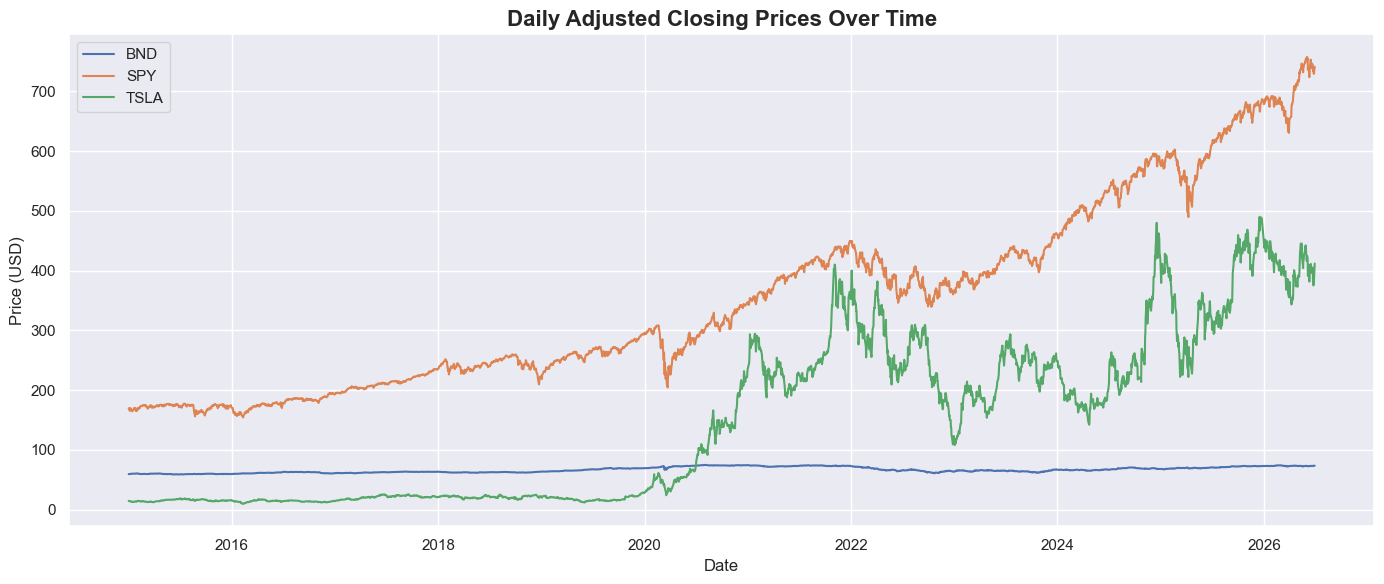

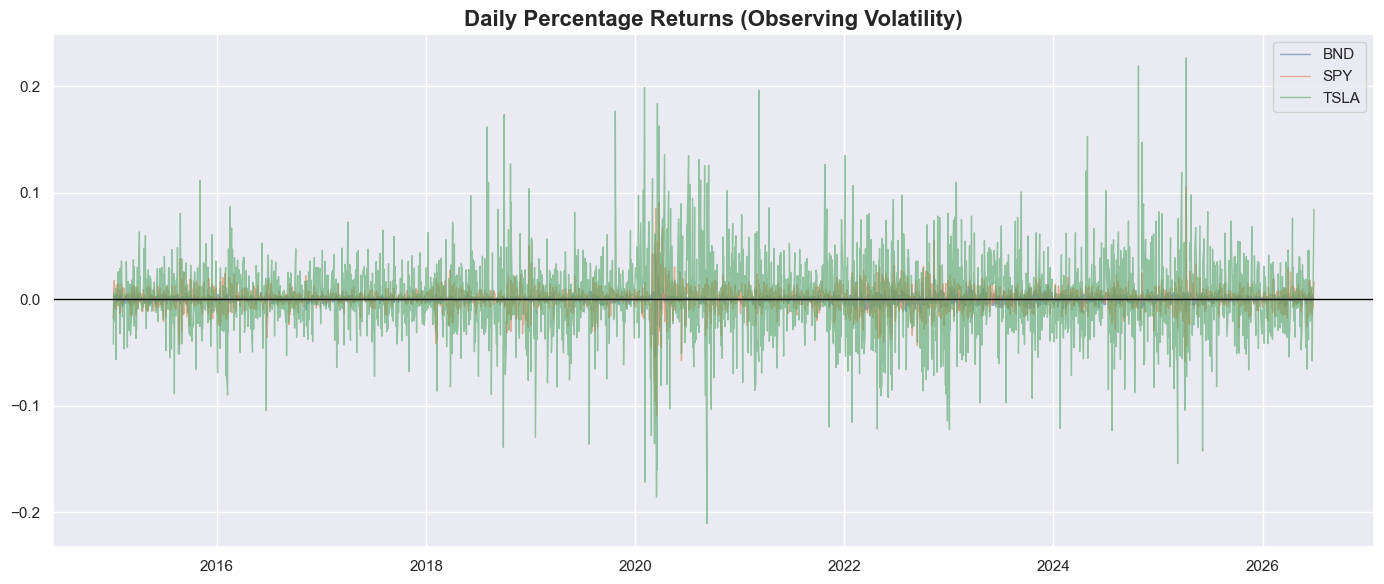

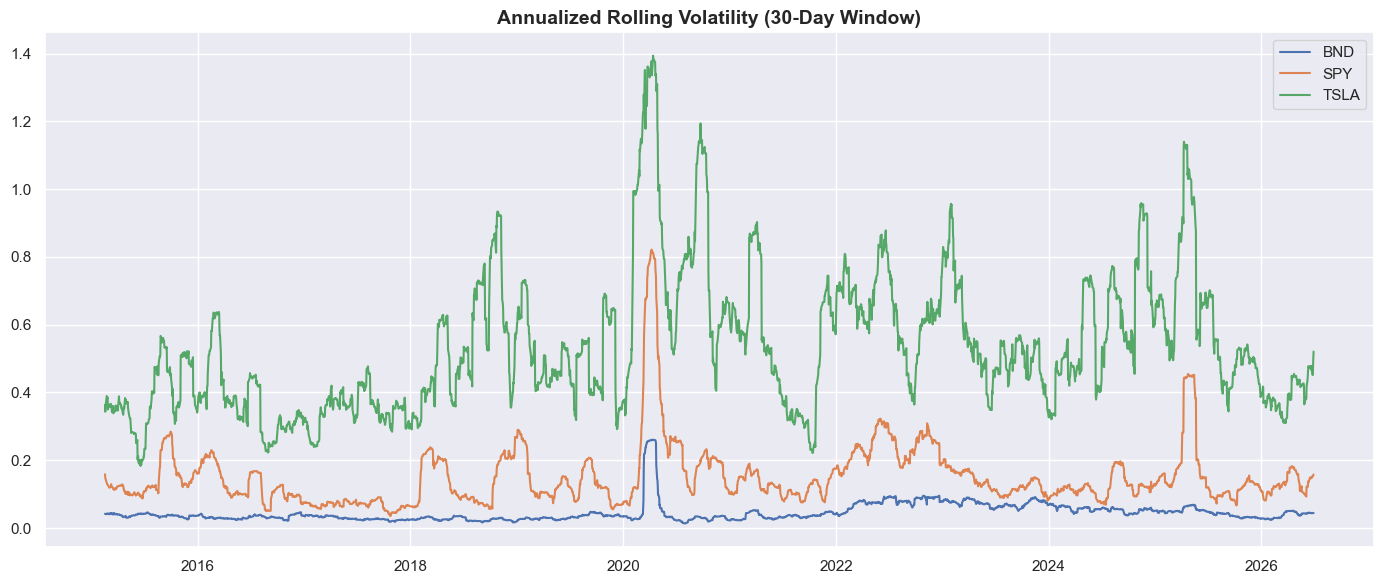

==== OUTLIER DETECTION ====


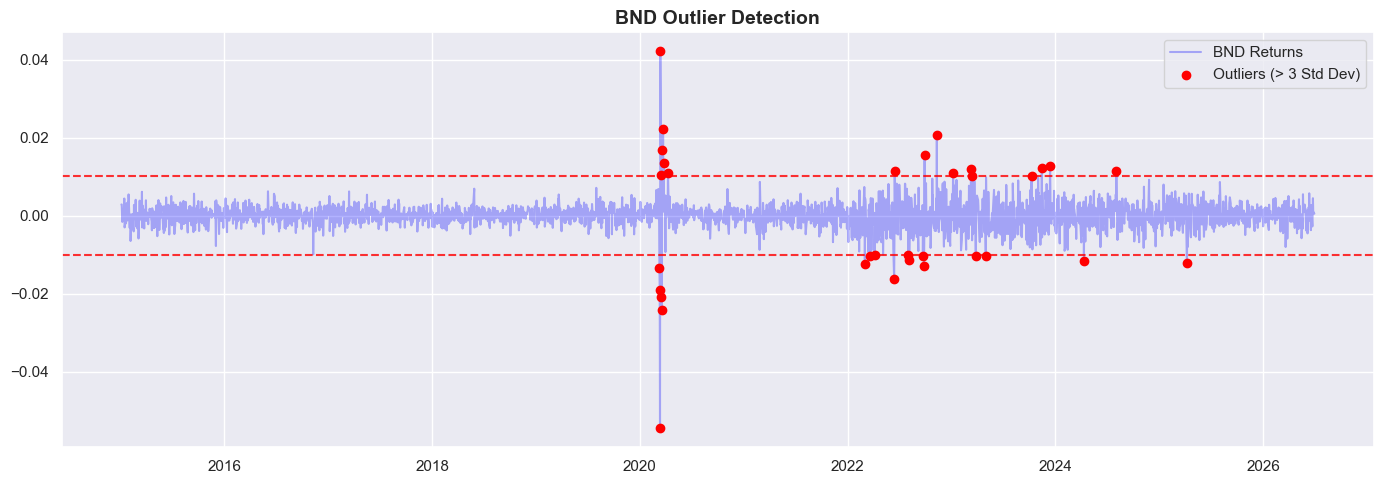

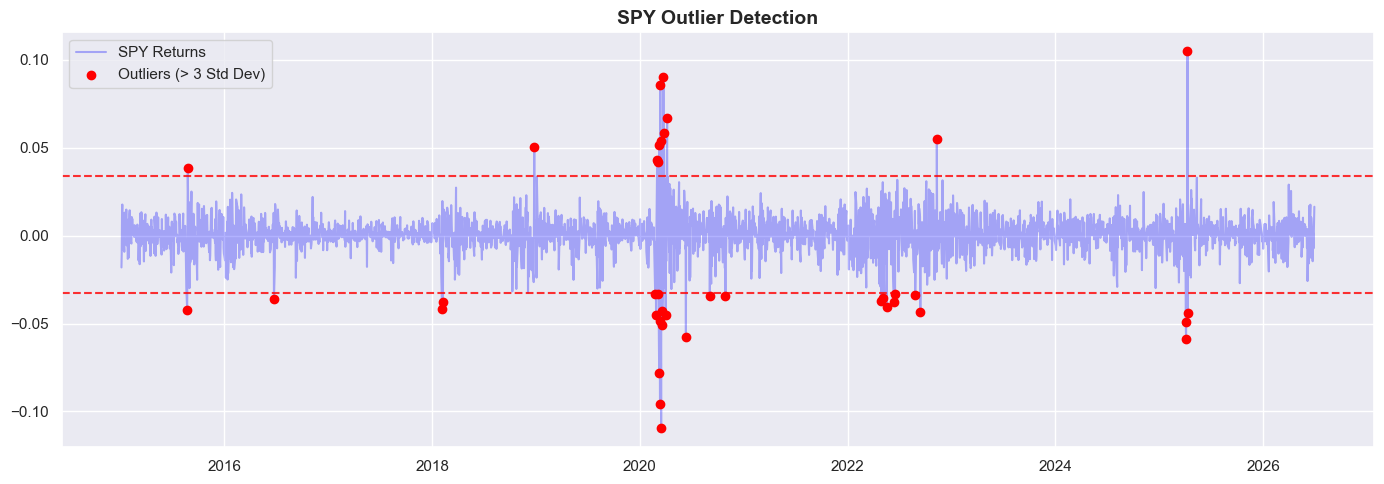

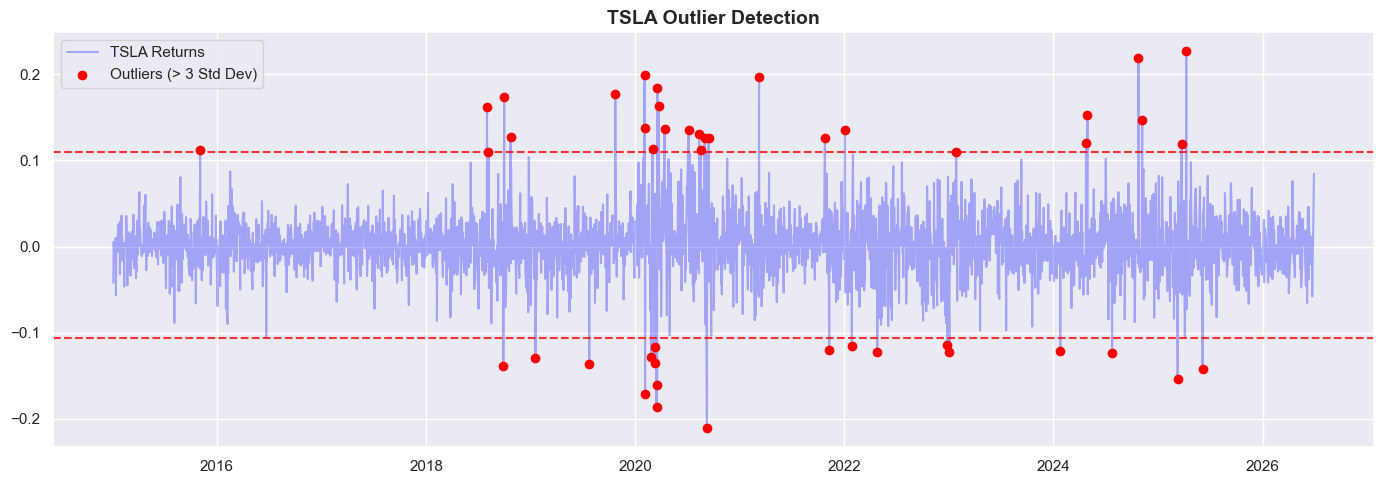


==== ADF STATIONARITY TEST ====
BND Price -> p-value: 0.7219 (Non-Stationary)
SPY Price -> p-value: 0.9967 (Non-Stationary)
TSLA Price -> p-value: 0.7270 (Non-Stationary)
BND Return -> p-value: 0.0000 (Stationary)
SPY Return -> p-value: 0.0000 (Stationary)
TSLA Return -> p-value: 0.0000 (Stationary)

==== RISK METRICS ====
BND | VaR (95%): -0.4756% | Annualized Sharpe Ratio: 0.3756
SPY | VaR (95%): -1.6650% | Annualized Sharpe Ratio: 0.8175
TSLA | VaR (95%): -5.1664% | Annualized Sharpe Ratio: 0.7944


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.tsa.stattools import adfuller

# Set a clean visual style for the EDA charts
sns.set_theme(style="darkgrid")

# --- DATA LOADING & CLEANING ---
# Assuming df_prices is already loaded from your extraction step. 
# Example: df_prices = pd.read_csv('../data/raw/asset_prices.csv', index_col=0, parse_dates=True)

# Interpolate missing values (time-based) and calculate returns
df_prices_cleaned = df_prices.interpolate(method='time')
df_returns_cleaned = df_prices_cleaned.pct_change().dropna()

# --- SCALING ---
min_max_scaler = MinMaxScaler()
df_minmax_scaled = pd.DataFrame(
    min_max_scaler.fit_transform(df_prices_cleaned), 
    columns=df_prices_cleaned.columns, 
    index=df_prices_cleaned.index
)

std_scaler = StandardScaler()
df_std_scaled_returns = pd.DataFrame(
    std_scaler.fit_transform(df_returns_cleaned),
    columns=df_returns_cleaned.columns,
    index=df_returns_cleaned.index
)

# --- VISUALIZATION 1: CLOSING PRICES OVER TIME ---
plt.figure(figsize=(14, 6))
for col in df_prices_cleaned.columns:
    plt.plot(df_prices_cleaned.index, df_prices_cleaned[col], label=col, linewidth=1.5)
plt.title('Daily Adjusted Closing Prices Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: DAILY RETURNS (VOLATILITY) ---
plt.figure(figsize=(14, 6))
for col in df_returns_cleaned.columns:
    plt.plot(df_returns_cleaned.index, df_returns_cleaned[col], label=col, alpha=0.6, linewidth=1)
plt.title('Daily Percentage Returns (Observing Volatility)', fontsize=16, fontweight='bold')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

# --- ROLLING MEANS & STANDARD DEVIATIONS ---
window_size = 30
rolling_mean = df_prices_cleaned.rolling(window=window_size).mean()
rolling_std = df_returns_cleaned.rolling(window=window_size).std() * np.sqrt(252)

plt.figure(figsize=(14, 6))
for col in rolling_std.columns:
    plt.plot(rolling_std.index, rolling_std[col], label=col, linewidth=1.5)
plt.title(f'Annualized Rolling Volatility ({window_size}-Day Window)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# --- OUTLIER DETECTION ---
print("==== OUTLIER DETECTION ====")
for col in df_returns_cleaned.columns:
    mean_ret = df_returns_cleaned[col].mean()
    std_ret = df_returns_cleaned[col].std()
    
    upper_bound = mean_ret + (3 * std_ret)
    lower_bound = mean_ret - (3 * std_ret)
    outliers = df_returns_cleaned[(df_returns_cleaned[col] > upper_bound) | (df_returns_cleaned[col] < lower_bound)][col]
    
    # VISUALIZATION 3: OUTLIERS
    plt.figure(figsize=(14, 5))
    plt.plot(df_returns_cleaned.index, df_returns_cleaned[col], label=f'{col} Returns', color='blue', alpha=0.3)
    plt.scatter(outliers.index, outliers.values, color='red', label='Outliers (> 3 Std Dev)', zorder=5)
    plt.axhline(upper_bound, color='red', linestyle='--', alpha=0.8)
    plt.axhline(lower_bound, color='red', linestyle='--', alpha=0.8)
    plt.title(f'{col} Outlier Detection', fontsize=14, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- SEASONALITY AND TREND ANALYSIS (ADF TEST) ---
print("\n==== ADF STATIONARITY TEST ====")
def run_adf_test(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]
    is_stationary = "Stationary" if p_value < 0.05 else "Non-Stationary"
    print(f"{name} -> p-value: {p_value:.4f} ({is_stationary})")

for col in df_prices_cleaned.columns: run_adf_test(df_prices_cleaned[col], f"{col} Price")
for col in df_returns_cleaned.columns: run_adf_test(df_returns_cleaned[col], f"{col} Return")

# --- RISK METRICS (VaR & SHARPE RATIO) ---
print("\n==== RISK METRICS ====")
for col in df_returns_cleaned.columns:
    var_95 = df_returns_cleaned[col].quantile(0.05)
    sharpe = (df_returns_cleaned[col].mean() / df_returns_cleaned[col].std()) * np.sqrt(252)
    print(f"{col} | VaR (95%): {var_95:.4%} | Annualized Sharpe Ratio: {sharpe:.4f}")

In [8]:
import numpy as np

print("==== RISK METRICS ====")

# 1. Value at Risk (VaR) - Historical Method at 95% Confidence
print("Value at Risk (VaR) at 95% Confidence Level:")
print("Interpretation: There is a 5% chance the asset will lose more than this percentage in a single day.")
for col in df_returns_cleaned.columns:
    # 0.05 quantile represents the worst 5% of daily returns
    var_95 = df_returns_cleaned[col].quantile(0.05)
    print(f" - {col} VaR (95%): {var_95:.4%} (A 1-day loss of at least {abs(var_95):.2%})")

# 2. Sharpe Ratio (Annualized)
print("\nAnnualized Sharpe Ratio (assuming Risk-Free Rate = 0%):")
print("Interpretation: > 1.0 is considered good risk-adjusted performance.")
for col in df_returns_cleaned.columns:
    mean_daily_return = df_returns_cleaned[col].mean()
    std_daily_return = df_returns_cleaned[col].std()
    
    # Annualize the Sharpe Ratio by multiplying by the square root of 252 trading days
    sharpe_ratio = (mean_daily_return / std_daily_return) * np.sqrt(252)
    print(f" - {col} Sharpe Ratio: {sharpe_ratio:.4f}")

==== RISK METRICS ====
Value at Risk (VaR) at 95% Confidence Level:
Interpretation: There is a 5% chance the asset will lose more than this percentage in a single day.
 - BND VaR (95%): -0.4756% (A 1-day loss of at least 0.48%)
 - SPY VaR (95%): -1.6650% (A 1-day loss of at least 1.67%)
 - TSLA VaR (95%): -5.1664% (A 1-day loss of at least 5.17%)

Annualized Sharpe Ratio (assuming Risk-Free Rate = 0%):
Interpretation: > 1.0 is considered good risk-adjusted performance.
 - BND Sharpe Ratio: 0.3756
 - SPY Sharpe Ratio: 0.8175
 - TSLA Sharpe Ratio: 0.7944
